In [81]:
import pandas as pd
import numpy as np

In [95]:
shared_genes = pd.read_csv("../data/processed/shared_genes.csv")
tumor_expr = pd.read_csv("../data/processed/tumor_expr.csv",index_col=0)
tumor_expr.index.names = ["gene_symbol"]
normal_expr = pd.read_csv("../data/processed/normal_expr_by_gene.csv",index_col=0)
normal_expr.index.names = ["gene_symbol"]

In [96]:
tumor_expr

,3744,3745,3746,3747,3748,3749,3751,3752,3753,3754,...,4785,4787,4788,4790,4791,4793,5063,5070,9907,9938
gene_symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,4.394662,2.354106,3.698237,3.061203,3.775243,3.208813,3.742346,4.450441,4.288143,2.937130,...,3.917022,3.595385,3.048537,3.243293,3.648094,3.310033,3.291145,3.720765,2.706173,3.524462
A1BG-AS1,2.358761,1.951971,2.678612,2.655038,2.314697,2.710291,3.580731,4.187108,2.490629,2.262827,...,2.454834,2.340871,3.665099,2.383732,3.182226,2.811773,2.602124,2.568453,2.675025,2.472905
A1CF,3.257421,3.630319,3.679696,3.380573,3.480199,3.917407,3.284112,3.648913,3.360726,3.882478,...,3.840961,3.678508,3.416684,3.816160,3.735301,3.748079,4.226380,4.161388,3.922684,3.142290
A2M,5.084398,4.995727,5.103459,4.502660,5.814636,4.906254,4.729053,5.454909,5.252507,4.842884,...,5.290655,5.863356,4.850680,5.397120,4.474637,5.301041,4.994559,4.875568,5.108188,4.880286
A2MP1,4.069778,4.064544,3.921959,3.508234,3.744714,3.417944,2.393006,2.224092,2.914121,3.331895,...,3.531832,3.611975,3.677654,3.435633,3.335988,3.536994,3.352463,3.615846,3.881333,3.532773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,1.914307,1.914307,3.499105,1.899114,2.107029,2.066537,2.207839,1.943952,1.281297,2.242604,...,2.403292,2.719353,2.014087,2.253038,2.030806,2.414216,2.003906,2.271015,1.784980,3.537713
ZYG11B,4.402573,5.006779,4.809271,4.696934,4.699575,4.969987,5.476676,4.959847,4.840276,5.287951,...,4.810740,4.742676,4.541625,4.596421,4.872326,4.961538,5.275811,5.042485,4.854385,5.041653
ZYX,4.109285,5.294653,5.154540,4.396038,5.288102,5.206903,3.949828,5.047741,4.923909,4.627737,...,4.024680,4.256629,3.867288,3.844997,4.555171,3.675503,3.951687,4.135060,3.694074,3.532166


In [97]:
normal_expr

,GSM300166,GSM300167,GSM300168,GSM300169,GSM300170,GSM300171,GSM300172,GSM300173,GSM300174,GSM300175,...,GSM300331,GSM300332,GSM300333,GSM300335,GSM300338,GSM300339,GSM300340,GSM300341,GSM318840,GSM350078
gene_symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,3.383635,3.440462,6.298831,5.891724,6.199747,6.363312,6.193192,3.464037,3.523349,3.443599,...,3.569553,3.428387,3.418871,3.508654,3.445991,3.444783,3.509258,3.467677,3.406322,3.541700
A1BG-AS1,2.369291,2.689417,3.164159,3.387460,3.036285,3.524049,3.525378,2.469777,2.376589,2.613155,...,3.571817,3.281033,3.333216,2.593902,2.726424,2.274999,1.916865,3.375156,2.570152,3.327683
A1CF,4.000236,3.695870,2.701450,2.623980,2.660830,2.421396,2.758660,3.562714,3.556193,3.510994,...,3.664106,3.654950,3.429371,3.645246,3.747081,3.646802,3.479669,3.747191,3.559086,3.620367
A2M,5.202047,4.882020,5.215863,6.062451,5.697620,5.752285,5.964075,4.938611,5.027418,5.091889,...,4.971117,5.482643,5.404915,4.842265,5.157118,5.302893,4.959655,5.008150,6.217503,4.871953
A2MP1,3.507175,3.535737,1.975684,1.938425,1.971219,1.927670,2.150863,3.613736,3.293150,3.350344,...,3.502135,3.553693,3.176404,3.569283,3.658523,3.312765,3.315846,3.609412,3.312750,3.512219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,2.587987,2.453702,0.307941,0.164384,0.265101,0.260189,0.430476,2.476246,2.561020,2.129993,...,2.312088,2.329765,2.284650,2.298130,2.554011,2.539369,1.787456,2.473302,2.187172,2.384363
ZYG11B,4.721756,4.744454,5.027853,4.756095,4.948456,4.691361,4.939316,5.106142,4.944249,5.118226,...,4.935708,4.547844,4.763759,4.935299,5.135349,4.895380,4.742342,4.825806,4.573292,5.216467
ZYX,4.742472,3.981167,4.916540,4.281726,4.885101,5.544005,4.784109,4.184615,3.332838,5.307084,...,4.998871,3.792791,3.700621,4.468916,3.812466,3.541744,5.326560,4.956504,4.450266,4.448682


In [98]:
from scipy.stats import ttest_ind, ttest_1samp

# Differential analysis: tumor vs normal on shared genes
shared_gene_list = shared_genes["gene_symbol"].astype(str).str.upper().tolist()

# Ensure gene symbols are uppercase and unique before alignment
tumor_expr.index = tumor_expr.index.astype(str).str.upper()
normal_expr.index = normal_expr.index.astype(str).str.upper()

# Keep only shared genes present in both matrices
common_genes = (
    pd.Index(shared_gene_list)
    .intersection(tumor_expr.index)
    .intersection(normal_expr.index)
)

# Gene x sample/value matrices
tumor_aligned = tumor_expr.loc[common_genes]
normal_aligned = normal_expr.loc[common_genes]

tumor_aligned = (
    tumor_aligned
    .groupby(tumor_aligned.index)
    .mean()
)

normal_aligned = (
    normal_aligned
    .groupby(normal_aligned.index)
    .mean()
)

# Mean expression and log2 fold change (tumor - normal)
tumor_mean = tumor_aligned.mean(axis=1)
normal_mean = normal_aligned.mean(axis=1)
log2fc = tumor_mean - normal_mean


In [104]:

# Per-gene significance test
# If normal has multiple samples, use Welch's t-test.
# If normal has one column, use one-sample t-test of tumor vs that normal mean.
pvals = []
for gene in tumor_aligned.index:
    tvals = tumor_aligned.loc[gene].dropna().values
    nvals = normal_aligned.loc[gene].dropna().values

    if len(tvals) < 2 or len(nvals) == 0:
        pvals.append(np.nan)
        continue

    if normal_aligned.shape[1] >= 2 and len(nvals) >= 2:
        pvals.append(ttest_ind(tvals, nvals, equal_var=False, nan_policy="omit").pvalue)
    else:
        pvals.append(ttest_1samp(tvals, popmean=float(nvals[0]), nan_policy="omit").pvalue)

pvals = pd.Series(pvals, index=tumor_aligned.index, name="pval")

# Benjamini-Hochberg FDR correction (fallback to raw p-values if unavailable)
try:
    from statsmodels.stats.multitest import multipletests
    p_adj = pd.Series(multipletests(pvals.fillna(1.0), method="fdr_bh")[1], index=pvals.index, name="p_adj")
except Exception:
    p_adj = pvals.copy()
    p_adj.name = "p_adj"

# Build result table
diff_results = pd.DataFrame({
    "gene_symbol": tumor_aligned.index,
    "tumor_mean": tumor_mean.values,
    "normal_mean": normal_mean.values,
    "log2FC_tumor_minus_normal": log2fc.values,
    "pval": pvals.values,
    "p_adj": p_adj.values,
}).set_index("gene_symbol")

diff_results["neg_log10_p_adj"] = -np.log10(diff_results["p_adj"].clip(lower=1e-300))

# Significance flags (same spirit as 02_generalanalysis)
fc_thresh = 1.0
p_thresh = 0.05
diff_results["significant"] = (
    (diff_results["p_adj"] < p_thresh)
    & (diff_results["log2FC_tumor_minus_normal"].abs() >= fc_thresh)
)

diff_results = diff_results.sort_values(["p_adj", "log2FC_tumor_minus_normal"], ascending=[True, False])

# Export for downstream notebook work
diff_results.to_csv("../data/processed/differential_tumor_vs_normal.csv")

top_diff_genes = diff_results.head(20)

print("Genes tested:", diff_results.shape[0])
print("Significant genes:", int(diff_results["significant"].sum()))
print("Saved: ../data/processed/differential_tumor_vs_normal.csv")
top_diff_genes["log2FC_tumor_minus_normal"].describe

Genes tested: 20841
Significant genes: 0
Saved: ../data/processed/differential_tumor_vs_normal.csv


<bound method NDFrame.describe of gene_symbol
MRFAP1          0.004097
CFL1            0.004086
LOC101060363    0.004048
ACTB            0.004043
TUBA1B          0.004036
ACTG1           0.003975
PPIA            0.003943
RPL23A          0.003843
SNORD42A        0.003836
RPL37A          0.003833
RPS16           0.003822
MIR3064         0.003816
MIR5047         0.003816
LOC101928826    0.003809
TPT1            0.003809
RPL41           0.003782
RPL39           0.003775
DDX5            0.003760
UBC             0.003760
RPS10           0.003758
Name: log2FC_tumor_minus_normal, dtype: float64>

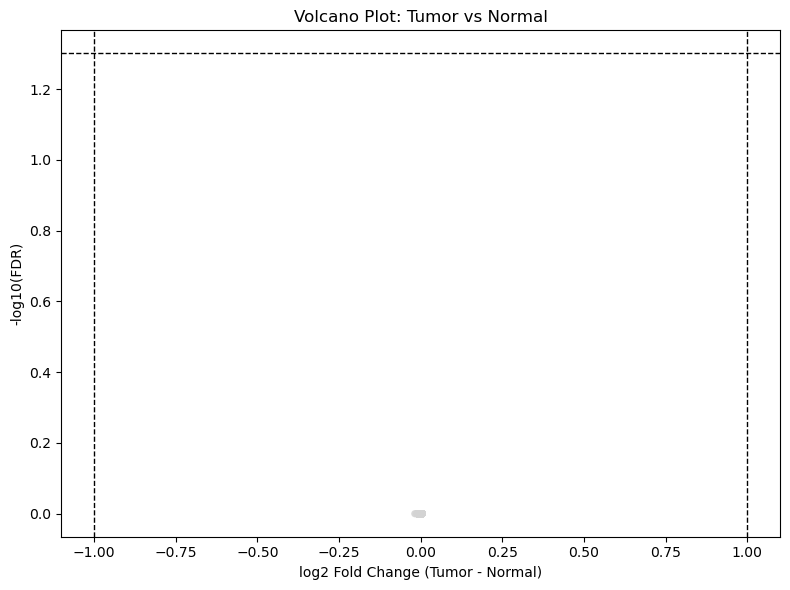

Saved: ../data/processed/differential_tumor_vs_normal_significant.csv


In [100]:
import matplotlib.pyplot as plt

# Volcano plot and export significant genes
plt.figure(figsize=(8, 6))
colors = np.where(
    diff_results["significant"],
    np.where(diff_results["log2FC_tumor_minus_normal"] >= 0, "crimson", "green"),
    "lightgray",
)

plt.scatter(
    diff_results["log2FC_tumor_minus_normal"],
    diff_results["neg_log10_p_adj"],
    c=colors,
    s=18,
    alpha=0.8,
)
plt.axvline(fc_thresh, color="black", linestyle="--", linewidth=1)
plt.axvline(-fc_thresh, color="black", linestyle="--", linewidth=1)
plt.axhline(-np.log10(p_thresh), color="black", linestyle="--", linewidth=1)
plt.xlabel("log2 Fold Change (Tumor - Normal)")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot: Tumor vs Normal")
plt.tight_layout()
plt.show()

sig_results = diff_results[diff_results["significant"]].copy()
sig_results.to_csv("../data/processed/differential_tumor_vs_normal_significant.csv")

print("Saved: ../data/processed/differential_tumor_vs_normal_significant.csv")

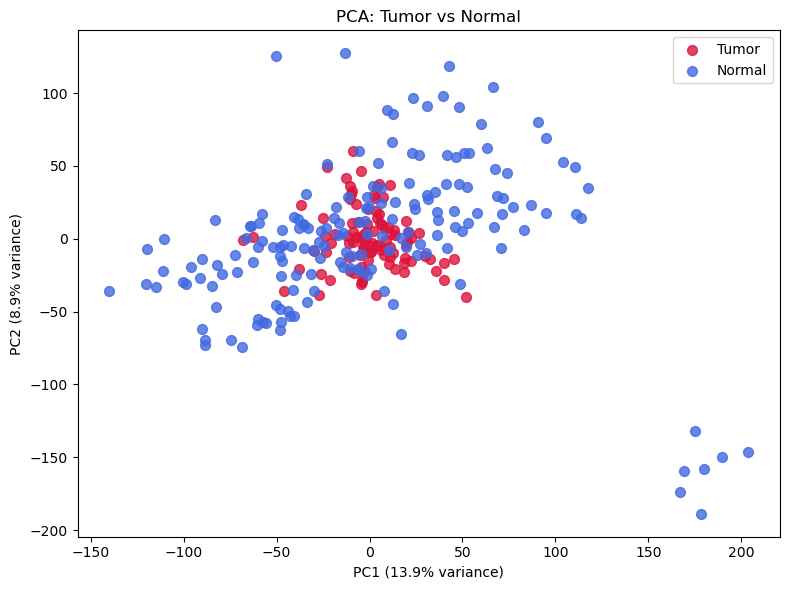

In [101]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA on samples (tumor samples + one normal reference point)
X_plot = pd.concat([tumor_aligned.T, normal_aligned.T], axis=0)
labels_plot = pd.Series(
    ["Tumor"] * tumor_aligned.shape[1] + ["Normal"] * normal_aligned.shape[1],
    index=X_plot.index,
)

X_plot = X_plot.apply(pd.to_numeric, errors="coerce")
X_plot = X_plot.fillna(X_plot.mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_plot)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
color_map = {"Tumor": "crimson", "Normal": "royalblue"}
for grp in labels_plot.unique():
    mask = labels_plot == grp
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=grp,
        color=color_map.get(grp, "gray"),
        alpha=0.8,
        s=50,
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA: Tumor vs Normal")
plt.legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()

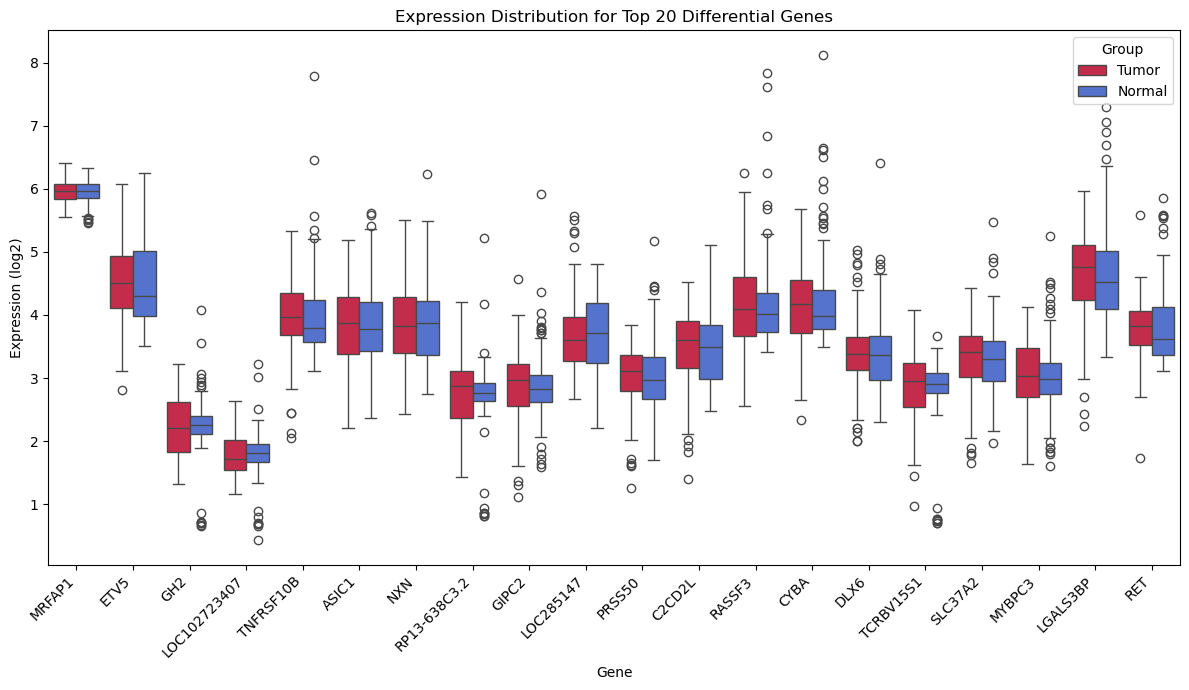

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot for top significant genes
top_n = 20
top_genes = diff_results.sort_values("p_adj").head(top_n).index.tolist()

expr_tumor = tumor_aligned.loc[top_genes].T.copy()
expr_tumor["group"] = "Tumor"

expr_normal = normal_aligned.loc[top_genes].T.copy()
expr_normal["group"] = "Normal"

plot_df = pd.concat([expr_tumor, expr_normal], axis=0).reset_index(drop=True)
plot_long = plot_df.melt(id_vars="group", var_name="gene_symbol", value_name="expression")

plt.figure(figsize=(max(12, top_n * 0.5), 7))
sns.boxplot(
    data=plot_long,
    x="gene_symbol",
    y="expression",
    hue="group",
    order=top_genes,
    palette={"Tumor": "crimson", "Normal": "royalblue"},
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Gene")
plt.ylabel("Expression (log2)")
plt.title(f"Expression Distribution for Top {top_n} Differential Genes")
plt.legend(title="Group", loc="best", frameon=True)
plt.tight_layout()
plt.show()

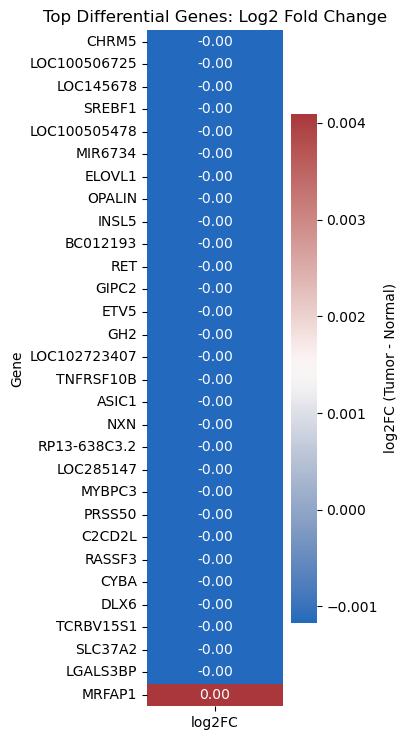

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap of log2 fold change for top differential genes
top_n = 30
ordered_genes = diff_results.sort_values("p_adj").head(top_n).sort_values("log2FC_tumor_minus_normal").index

heatmap_fc = diff_results.loc[ordered_genes, ["log2FC_tumor_minus_normal"]].copy()
heatmap_fc = heatmap_fc.rename(columns={"log2FC_tumor_minus_normal": "log2FC"})

plt.figure(figsize=(4, max(6, top_n * 0.25)))
sns.heatmap(
    heatmap_fc,
    cmap="vlag",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "log2FC (Tumor - Normal)"},
)
plt.title("Top Differential Genes: Log2 Fold Change")
plt.ylabel("Gene")
plt.xlabel("")
plt.tight_layout()
plt.show()